# NAMA      : SRI ZUL'AINI ULYA
# NIM       : F1D02410096
# KELOMPOK  : 10

In [159]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

## Import Library

Sebelum memulai pengolahan citra digital, kita perlu mengimpor library utama yang akan menjadi tulang punggung program ini:

* Pertama, kita menggunakan `numpy`. Karena citra digital dibaca oleh komputer sebagai kumpulan matriks berskala besar, kita membutuhkan *numpy* untuk melakukan operasi numerik dan manipulasi susunan *array* tersebut secara cepat.
* Kedua, kita membutuhkan `matplotlib.pyplot` untuk melihat hasil kerja kita. Pustaka ini bertugas menangani visualisasi data sehingga kita bisa menampilkan wujud gambar sekaligus melihat grafik distribusi warnanya melalui histogram.

Secara keseluruhan, sinergi antara perhitungan matematis dari *numpy* dan kemampuan visual dari *matplotlib* adalah fondasi utama kita dalam memanipulasi piksel dan menganalisis intensitas citra.

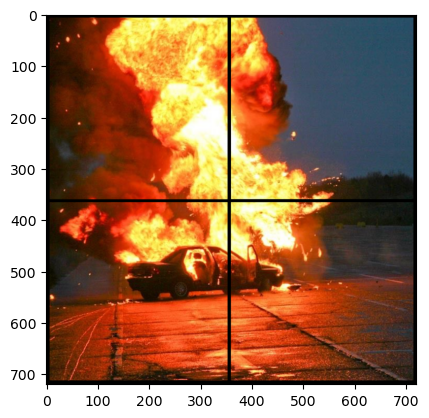

In [160]:
def show(img, title=""):
    plt.imshow(img, cmap='gray')
    plt.title(title)  
    plt.axis('on')

meledak = plt.imread("assets/Meledak.png")
show(meledak)

## Fungsi Menampilkan Citra

Fungsi `show()` dirancang khusus untuk memfasilitasi visualisasi citra pasca-pengolahan dengan memanfaatkan pustaka `matplotlib`. Modul ini terdiri dari beberapa komponen utama:

* `plt.imshow(img, cmap='gray')`: Bertugas merender citra secara visual. Penggunaan argumen `cmap='gray'` menginstruksikan sistem untuk menampilkan citra dalam format *grayscale*, yang mengoptimalkan proses analisis terhadap nilai intensitas piksel.
* `plt.title(title)`: Berfungsi menyematkan label atau judul pada representasi visual, guna membedakan luaran dari masing-masing tahapan pemrosesan dengan jelas.
* `plt.axis('on')`: Mengaktifkan tampilan sumbu referensi spasial (koordinat x dan y) untuk mempermudah identifikasi posisi absolut dari piksel yang diamati.

Secara keseluruhan, implementasi fungsi ini secara efektif mengeliminasi redundansi penulisan kode dan meningkatkan efisiensi proses visualisasi pada setiap fase pengolahan citra.

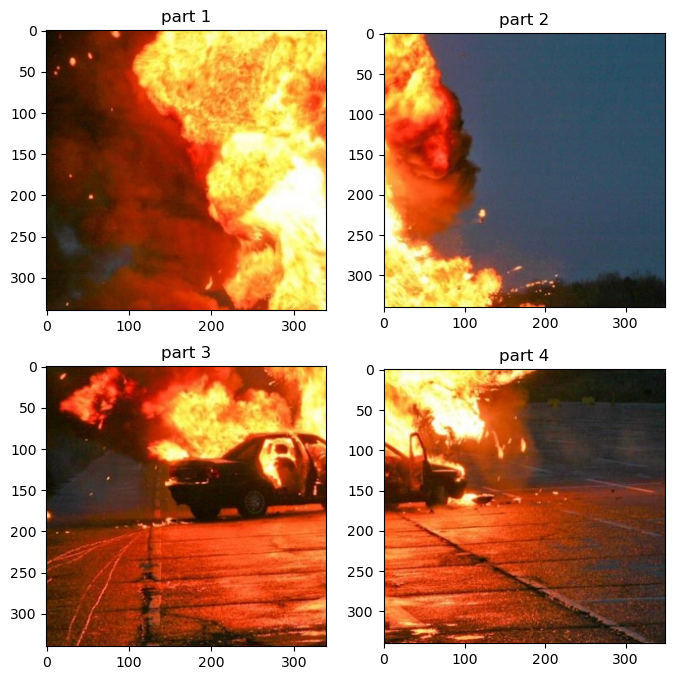

In [161]:
def slicing(gambar, a, b, mode='H'): 
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

vertical1 = slicing(meledak, 10, 350, 'V')
vertical2 = slicing(meledak, 360, 710, 'V')

potongan1 = slicing(vertical1, 10, 350, 'H')
potongan2 = slicing(vertical2, 10, 350, 'H')
potongan3 = slicing(vertical1, 370, 710, 'H')
potongan4 = slicing(vertical2, 370, 710, 'H')

plt.figure(figsize=(8, 8))
plt.subplot(2,2,1)
show(potongan1, "part 1")
plt.subplot(2,2,2)
show(potongan2, "part 2")
plt.subplot(2,2,3)
show(potongan3, "part 3")
plt.subplot(2,2,4)
show(potongan4, "part 4")
plt.show()

## Pemotongan Citra (Image Slicing)

Dalam pengolahan citra digital, seringkali kita hanya memerlukan area tertentu dari sebuah gambar untuk diproses lebih lanjut. Teknik mengekstrak area spesifik ini dikenal sebagai *slicing* (pengirisan) atau *cropping*. Karena citra pada dasarnya direpresentasikan sebagai matriks (susunan *array*), proses *slicing* dapat dilakukan secara efisien dengan membatasi rentang indeks baris (merepresentasikan tinggi) dan kolom (merepresentasikan lebar) pada matriks tersebut.

Pada tahap ini, kita mendefinisikan sebuah fungsi dinamis untuk memotong citra secara horizontal maupun vertikal. Fungsi ini kemudian dimanfaatkan untuk memecah citra latar belakang yang utuh menjadi empat potongan matriks terpisah (kuadran).

## Logika Pemecahan Kuadran Citra

Implementasi di atas terbagi menjadi proses pendefinisian fungsi dan eksekusi pemotongan bersusun:

* **Fungsi `slicing(gambar, a, b, mode)`**: Berfungsi sebagai instrumen pemotong matriks. Jika `mode='H'` (Horizontal), rentang indeks membatasi sumbu *y* atau baris (`gambar[a:b, :]`). Jika mode bukan 'H' (Vertikal), rentang indeks membatasi sumbu *x* atau kolom (`gambar[:, a:b]`).
* **Pemotongan Tahap 1 (Vertikal)**: Citra direduksi menjadi dua bagian utama, yaitu sisi kiri (`vertical1`) dan kanan (`vertical2`), menggunakan irisan berbasis kolom. Area di antara batas irisan (seperti celah piksel 350 hingga 360) secara otomatis terbuang.
* **Pemotongan Tahap 2 (Horizontal)**: Masing-masing irisan vertikal dipotong kembali secara mendatar. Hasil dari pemotongan ganda ini adalah empat bagian citra terpisah (`potongan1` hingga `potongan4`) yang merepresentasikan empat sudut gambar asli.
* **Visualisasi Grid**: Penggunaan parameter tata letak (seperti `plt.subplot`) memfasilitasi penempatan keempat potongan citra ke dalam satu kanvas visual secara serentak untuk memverifikasi akurasi koordinat pemotongan.

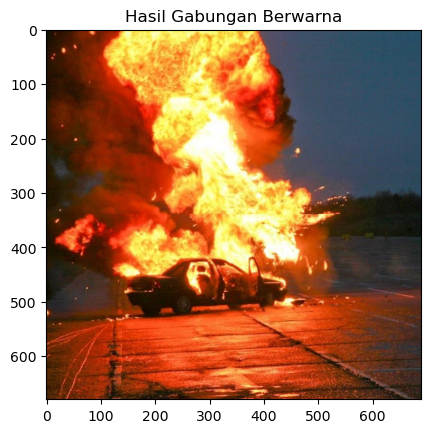

In [162]:
def merge_atas(image_1, image_2): 
    c1, c2 = np.array(image_1), np.array(image_2) 
    tinggi = max(c1.shape[0], c2.shape[0]) 
    lebar = c1.shape[1] + c2.shape[1] 
    if len(c1.shape) == 3:
        hasil = np.zeros((tinggi, lebar, c1.shape[2]), dtype=c1.dtype)
    else:
        hasil = np.zeros((tinggi, lebar), dtype=c1.dtype)
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1 
    hasil[0:c2.shape[0], c1.shape[1]:] = c2 
    return hasil

def merge_bawah(image_3, image_4): 
    c1, c2 = np.array(image_3), np.array(image_4)
    tinggi = c1.shape[0] + c2.shape[0] 
    lebar = max(c1.shape[1], c2.shape[1]) 
    if len(c1.shape) == 3:
        hasil = np.zeros((tinggi, lebar, c1.shape[2]), dtype=c1.dtype)
    else:
        hasil = np.zeros((tinggi, lebar), dtype=c1.dtype)
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2
    return hasil

baris1 = merge_atas(potongan1, potongan2)
baris2 = merge_atas(potongan3, potongan4)
meledak_utuh = merge_bawah(baris1, baris2)

show(meledak_utuh, "Hasil Gabungan Berwarna")

## Rekonstruksi Citra (Image Merging)

Setelah citra dipecah menjadi beberapa potongan kuadran, tahap selanjutnya adalah merekonstruksinya kembali menjadi satu kesatuan utuh. Proses ini dilakukan dengan mengalokasikan matriks kosong (kanvas) baru, lalu menempelkan susunan piksel dari masing-masing potongan ke dalam titik koordinat yang tepat. 

Implementasi ini terbagi menjadi fungsi penggabung dan tahap eksekusi:

* **Fungsi `merge_atas` (Penggabungan Horizontal)**: Bertugas menempelkan dua gambar secara berdampingan (kiri dan kanan). Lebar kanvas baru yang dibuat adalah hasil penjumlahan lebar kedua gambar, sedangkan tingginya mengikuti tinggi maksimum dari keduanya.
* **Fungsi `merge_bawah` (Penggabungan Vertikal)**: Bertugas menumpuk dua gambar secara atas-bawah. Tinggi kanvas baru adalah hasil penjumlahan tinggi kedua gambar, sedangkan lebarnya menyesuaikan dengan ukuran terlebar di antara keduanya.
* **Deteksi Dimensi Fleksibel**: Kedua fungsi tersebut mengimplementasikan kondisional `if len(c1.shape) == 3` untuk mendeteksi secara otomatis apakah citra yang masuk berwarna (3 *channel*) atau *grayscale* (2 *channel*), sehingga alokasi memori kanvas kosong (`np.zeros`) selalu tepat sasaran.
* **Proses Eksekusi**: Potongan kuadran digabungkan secara horizontal terlebih dahulu menjadi `baris1` (atas) dan `baris2` (bawah). Kedua baris tersebut kemudian ditumpuk secara vertikal untuk menghasilkan citra latar belakang yang utuh kembali (`meledak_utuh`).

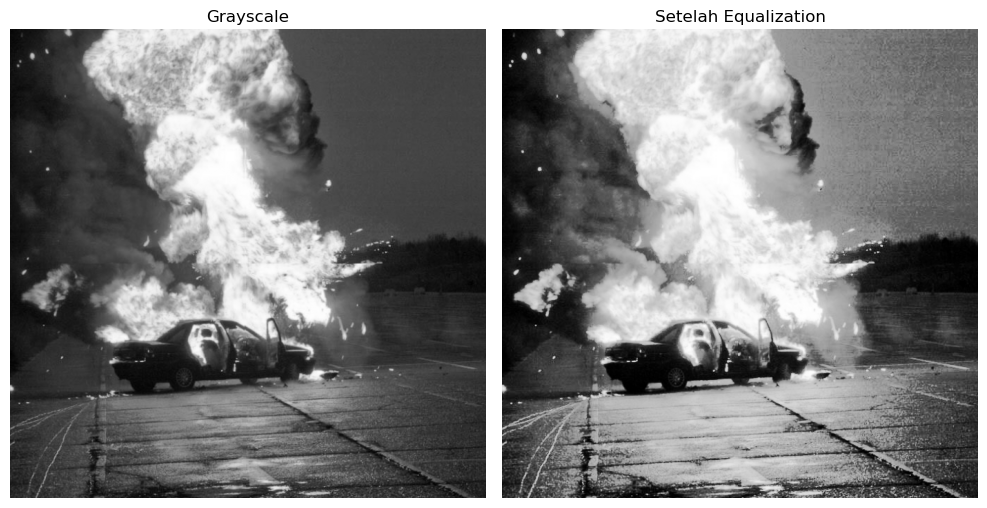

In [173]:
def equalization(image):
    height, width = image.shape
    hist = np.zeros(256, dtype=int)

    for y in range(height):
        for x in range(width):
            nilai_piksel = image[y, x]
            hist[nilai_piksel] += 1
            
    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]
    
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]
        
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)
    result = np.zeros_like(image, dtype=np.uint8)
    
    for y in range(height):
        for x in range(width):
            nilai_piksel = image[y, x]
            result[y, x] = cdf_normal[nilai_piksel]
            
    return result

img_gray = cv.cvtColor(meledak_utuh, cv.COLOR_RGB2GRAY)
if img_gray.dtype != np.uint8:
    img_gray = (img_gray * 255).astype(np.uint8)

img_equalized = equalization(img_gray)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_equalized, cmap='gray')
plt.title("Setelah Equalization")
plt.axis('off')

plt.tight_layout()
plt.show()

## Ekualisasi Histogram (Histogram Equalization)

Ekualisasi histogram adalah teknik pemrosesan citra yang digunakan untuk meningkatkan kontras secara global. Algoritma ini bekerja dengan meratakan distribusi intensitas piksel, sehingga area citra yang terlalu gelap atau terlalu terang dapat menampilkan detail tekstur yang lebih tajam dan jelas. 

Implementasi manual dari algoritma ini dibagi menjadi beberapa tahapan matematis dan eksekusi visual:

* **Perhitungan Histogram (`hist`)**: Melakukan iterasi pada seluruh matriks citra untuk menghitung frekuensi atau jumlah kemunculan setiap nilai intensitas piksel (dalam rentang 0 hingga 255).
* **Distribusi Kumulatif (`cdf`)**: Menghitung *Cumulative Distribution Function* (CDF) dengan mengakumulasikan nilai frekuensi piksel secara berurutan. Proses ini memetakan probabilitas kumulatif dari tingkat kecerahan citra.
* **Normalisasi dan Pemetaan (`cdf_normal`)**: Mentransformasi nilai CDF ke dalam rentang standar piksel *uint8* (0-255). Matriks citra kosong (`result`) kemudian diisi dengan memetakan nilai piksel citra asli ke nilai kecerahan baru yang telah disetarakan.
* **Pra-pemrosesan (*Grayscale*)**: Fungsi ekualisasi dasar beroperasi pada saluran intensitas tunggal. Oleh karena itu, citra `meledak_utuh` harus dikonversi dari format berwarna (RGB/BGR) menjadi *grayscale* sebelum diproses.
* **Visualisasi Komparatif**: Tata letak grid `plt.subplot(1, 2, x)` digunakan untuk menyandingkan citra *grayscale* asli dengan citra hasil ekualisasi secara horizontal (*side-by-side*), mempermudah analisis visual terhadap peningkatan kontras yang terjadi.

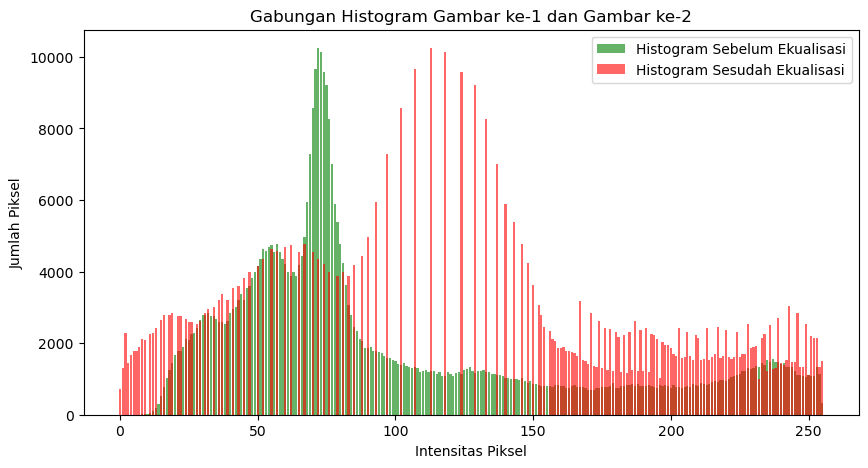

In [164]:
def make_hist(image):
    histogram = [0] * 256
    height = len(image)
    width = len(image[0]) if height > 0 else 0
    for i in range(height):
        for j in range(width):
            val = int(image[i][j])
            histogram[val] += 1
    return histogram

def plot_histogram(histogram, title, ImgColor):
    plt.figure(figsize=(10, 5))
    plt.xlabel("Intensitas Piksel")
    plt.title(title)
    plt.ylabel("Jumlah Piksel")
    plt.bar(range(256), histogram, color=ImgColor, width=0.8)
    plt.show()

hist_sebelum = make_hist(img_gray)
hist_sesudah = make_hist(img_equalized)

plt.figure(figsize=(10, 5))
plt.title("Gabungan Histogram Gambar ke-1 dan Gambar ke-2")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")

plt.bar(range(256), hist_sebelum, color='green', alpha=0.6, width=0.8, label='Histogram Sebelum Ekualisasi')

plt.bar(range(256), hist_sesudah, color='red', alpha=0.6, width=0.8, label='Histogram Sesudah Ekualisasi')

plt.legend()
plt.show()

## Analisis dan Visualisasi Histogram

Setelah melakukan proses ekualisasi, tahap krusial berikutnya adalah memvalidasi transformasi tersebut secara kuantitatif dan visual. Histogram merupakan representasi grafis yang menunjukkan distribusi frekuensi dari nilai intensitas piksel pada sebuah citra. 

Implementasi kode ini dirancang untuk menghitung dan membandingkan persebaran piksel secara langsung melalui beberapa tahapan:

* **Kalkulasi Frekuensi Manual (`make_hist`)**: Fungsi ini menginisialisasi *array* kosong dengan 256 elemen (merepresentasikan rentang kecerahan 0-255). Melalui perulangan ganda, algoritma akan membaca setiap piksel dan menambahkan nilai `+1` pada indeks *array* yang sesuai dengan intensitas piksel tersebut.
* **Fungsi Visualisasi Mandiri (`plot_histogram`)**: Sebuah modul pembantu yang didefinisikan untuk merender grafik batang (*bar chart*) tunggal menggunakan parameter pustaka Matplotlib, mencakup penamaan sumbu dan kustomisasi warna.
* **Plotting Komparatif (*Overlay*)**: Untuk mempermudah analisis perbandingan, distribusi piksel dari citra asli (sebelum ekualisasi) dan citra hasil diproyeksikan ke dalam satu sistem koordinat yang sama.
* **Manipulasi Transparansi (`alpha`)**: Penggunaan parameter `alpha=0.6` menginstruksikan sistem untuk memberikan efek semi-transparan pada grafik batang. Teknik ini memastikan bahwa ketika histogram hijau (sebelum) dan merah (sesudah) saling tumpang tindih, area irisannya tetap terlihat dan tidak ada data yang tersembunyi.

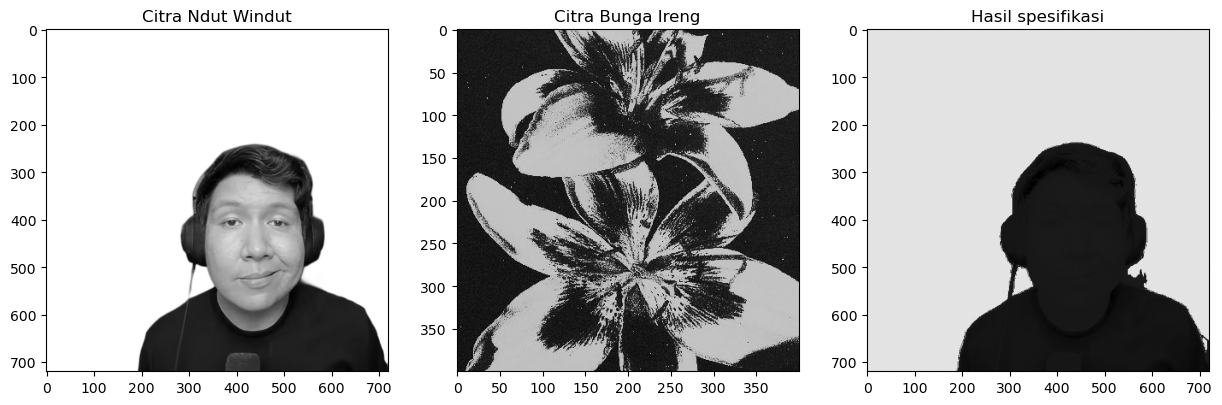

In [165]:
def histogram_specification(source_image, target_image):
    hist_source = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)
    height_s, width_s = source_image.shape
    for y in range(height_s):
        for x in range(width_s):
            val = source_image[y, x]
            hist_source[val] += 1
            
    height_t, width_t = target_image.shape
    for y in range(height_t):
        for x in range(width_t):
            val = target_image[y, x]
            hist_target[val] += 1

    cdf_source = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)
    cdf_source[0] = hist_source[0]
    cdf_target[0] = hist_target[0]
    
    for i in range(1, 256):
        cdf_source[i] = cdf_source[i - 1] + hist_source[i]
        cdf_target[i] = cdf_target[i - 1] + hist_target[i]

    cdf_source = cdf_source / cdf_source[-1]
    cdf_target = cdf_target / cdf_target[-1]
    
    map_hist = np.zeros(256, dtype=np.uint8)
    
    for i in range(256):
        min_diff = float('inf')
        best_j = 0
        for j in range(256):
            diff = abs(cdf_source[i] - cdf_target[j])
            if diff < min_diff:
                min_diff = diff
                best_j = j
        map_hist[i] = best_j

    height, width = source_image.shape
    result = np.zeros((height, width), dtype=np.uint8)
    
    for y in range(height):
        for x in range(width):
            val_lama = source_image[y, x]
            result[y, x] = map_hist[val_lama]
            
    return result

windut = cv.imread('assets/Windut.png', cv.IMREAD_GRAYSCALE)
bunga = cv.imread('assets/Bunga.png', cv.IMREAD_GRAYSCALE)

hasil_spesifikasi = histogram_specification(windut, bunga)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(windut, cmap='gray', vmin=0, vmax=255)
plt.title("Citra Ndut Windut")

plt.subplot(1, 3, 2)
plt.imshow(bunga, cmap='gray', vmin=0, vmax=255)
plt.title("Citra Bunga Ireng")

plt.subplot(1, 3, 3)
plt.imshow(hasil_spesifikasi, cmap='gray', vmin=0, vmax=255)
plt.title("Hasil spesifikasi")

plt.show()

## Spesifikasi Histogram (Histogram Specification)

Spesifikasi histogram (atau *histogram matching*) adalah teknik pemrosesan citra tingkat lanjut yang digunakan untuk mengubah distribusi intensitas sebuah citra agar menyerupai bentuk histogram dari citra referensi (target). Berbeda dengan ekualisasi yang sekadar meratakan histogram, teknik ini memaksa citra sumber untuk meniru karakteristik kontras dan pencahayaan dari citra lain secara spesifik.

Implementasi manual dari algoritma ini dilakukan melalui serangkaian pemrosesan matematis:

* **Kalkulasi Histogram dan CDF**: Algoritma menghitung frekuensi kemunculan piksel (histogram) dan *Cumulative Distribution Function* (CDF) secara paralel untuk citra sumber (`windut`) maupun citra target (`bunga`). Nilai CDF tersebut kemudian dinormalisasi menjadi rentang probabilitas 0 hingga 1.
* **Pencarian Probabilitas Terdekat (Pemetaan)**: Tahap ini merupakan inti dari algoritma spesifikasi. Untuk setiap tingkat kecerahan pada citra sumber, program mencari tingkat kecerahan pada citra target yang memiliki nilai probabilitas kumulatif (CDF) dengan selisih paling kecil (`min_diff`). Nilai kecerahan target yang paling cocok ini kemudian disimpan ke dalam matriks pemetaan (`map_hist`).
* **Transformasi Citra Sumber**: Setelah tabel pemetaan (*lookup table*) terbentuk, program melakukan iterasi pada matriks citra sumber dan mensubstitusi setiap nilai piksel lamanya dengan nilai baru berdasarkan `map_hist`, menghasilkan matriks citra baru dengan karakteristik rona citra target.
* **Visualisasi Komparatif**: Luaran divisualisasikan dalam format *grid* 1x3 menggunakan `plt.subplot`. Citra sumber disandingkan dengan citra target dan hasil akhir, memungkinkan observasi langsung terhadap perubahan karakteristik keabuan dengan menjaga rentang skala tetap dari 0-255 (`vmin=0, vmax=255`).

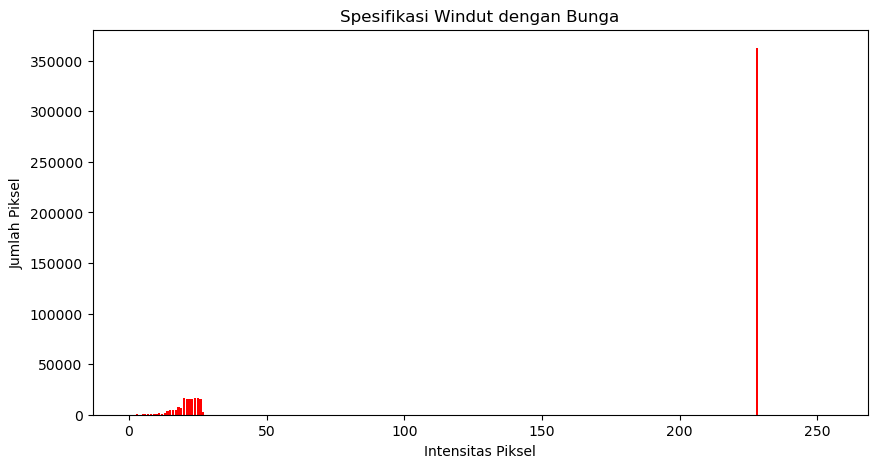

In [166]:
hist_hasil = make_hist(hasil_spesifikasi)

plot_histogram(hist_hasil, "Spesifikasi Windut dengan Bunga", "red")

## Visualisasi Hasil Spesifikasi Histogram

Setelah citra sumber berhasil ditransformasi, langkah terakhir adalah memvalidasi hasil tersebut melalui analisis grafik. Visualisasi ini berfungsi sebagai bukti empiris untuk memastikan bahwa karakteristik kontras citra telah benar-benar berubah sesuai dengan citra target.

Tahapan visualisasi ini mencakup dua proses ringkas:

* **Ekstraksi Data Kuantitatif (`make_hist`)**: Fungsi ini dipanggil kembali untuk menghitung distribusi frekuensi intensitas piksel secara spesifik dari matriks citra hasil transformasi (`hasil_spesifikasi`).
* **Representasi Grafis (`plot_histogram`)**: Data array hasil perhitungan tersebut kemudian dirender menjadi grafik batang berwarna merah. 
* **Tujuan Analisis**: Melalui grafik ini, kita dapat melakukan komparasi visual. Jika algoritma spesifikasi beroperasi dengan benar, bentuk dan sebaran histogram kemerahan ini seharusnya sudah tidak lagi menyerupai histogram citra sumber aslinya, melainkan telah bergeser dan meniru pola distribusi dari histogram citra target.

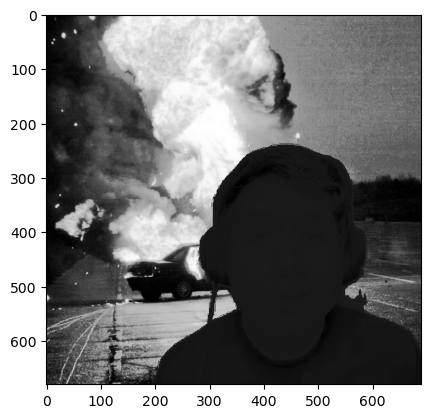

In [167]:
h_min = min(img_equalized.shape[0], hasil_spesifikasi.shape[0])
w_min = min(img_equalized.shape[1], hasil_spesifikasi.shape[1])

bg_cropped = img_equalized[0:h_min, 0:w_min]
fg_cropped = hasil_spesifikasi[0:h_min, 0:w_min]

hasil_masking = np.zeros((h_min, w_min), dtype=np.uint8)

for y in range(h_min):
    for x in range(w_min):
        intensitas_windut = fg_cropped[y, x]
        
        if intensitas_windut < 128:
            hasil_masking[y, x] = intensitas_windut
        else:
            hasil_masking[y, x] = bg_cropped[y, x]

plt.imshow(hasil_masking, cmap='gray')
plt.show()

## Penggabungan Citra Menggunakan Masking Thresholding

Tahap akhir dari alur pemrosesan ini adalah menggabungkan citra latar belakang yang telah diekualisasi (`img_equalized`) dengan citra objek yang telah dispesifikasi histogramnya (`hasil_spesifikasi`). Penggabungan ini tidak dilakukan secara tumpang tindih biasa, melainkan menggunakan logika seleksi kondisi berbasis ambang batas (*thresholding*) pada nilai intensitas keabuan.

Implementasi algoritma *masking* ini terdiri dari beberapa langkah operasional:

* **Sinkronisasi Dimensi (Slicing)**: Karena kedua citra mungkin memiliki resolusi yang berbeda, algoritma mencari dimensi terkecil (`h_min`, `w_min`) dan memotong (*cropping*) kedua matriks agar ukurannya menjadi identik. Hal ini krusial untuk mencegah *error* saat operasi pemetaan matriks piksel demi piksel.
* **Inisialisasi Kanvas**: Membuat matriks dua dimensi berukuran sinkron yang diisi nilai nol (`np.zeros`) bertipe data `uint8` sebagai ruang penyimpanan citra hasil gabungan.
* **Logika Masking Berbasis Intensitas**: Melalui perulangan ganda pada sumbu X dan Y, program menyeleksi setiap piksel berdasarkan nilai keabuannya.
* **Penerapan Ambang Batas (*Threshold 128*)**: Algoritma memeriksa intensitas piksel pada citra objek (Windut). Jika nilai intensitas berada di bawah 128 (merepresentasikan area objek yang cenderung lebih gelap), maka piksel asli tersebut dipertahankan pada kanvas. Sebaliknya, jika nilainya 128 ke atas (merepresentasikan area latar belakang asli yang terang/putih), posisi tersebut akan digantikan oleh piksel dari citra latar belakang (ledakan).
* **Visualisasi Akhir**: Citra matriks hasil seleksi logika tersebut dirender secara visual menggunakan argumen `cmap='gray'` untuk merepresentasikan komposit citra monokromatik yang utuh.

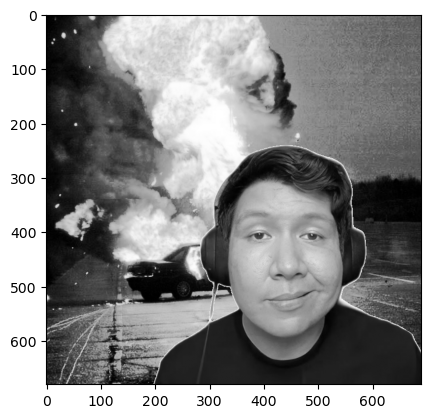

In [168]:
h_min = min(img_equalized.shape[0], windut.shape[0])
w_min = min(img_equalized.shape[1], windut.shape[1])

bg_cropped = img_equalized[0:h_min, 0:w_min]
windut_cropped = windut[0:h_min, 0:w_min]
hasil_akhir = np.zeros((h_min, w_min), dtype=np.uint8)

batas_putih = 245

for y in range(h_min):
    for x in range(w_min):
        intensitas_windut = windut_cropped[y, x]
        if intensitas_windut < batas_putih:
            hasil_akhir[y, x] = intensitas_windut
        else:
            hasil_akhir[y, x] = bg_cropped[y, x]

plt.imshow(hasil_akhir, cmap='gray', vmin=0, vmax=255)
plt.show()

## Penggabungan Citra Grayscale (White Threshold Masking)

Tahap ini merupakan proses penggabungan citra objek *grayscale* asli (`windut`) dengan citra latar belakang yang telah diekualisasi (`img_equalized`). Berbeda dengan proses sebelumnya, seleksi piksel pada tahap ini difokuskan untuk mengeliminasi latar belakang objek yang berwarna putih terang secara presisi.

Algoritma *masking* ini dijalankan melalui beberapa tahapan sistematis:

* **Penyelarasan Dimensi Matriks**: Kedua matriks citra dipotong (*cropped*) menggunakan ukuran minimum dari tinggi (`h_min`) dan lebar (`w_min`) yang sama. Hal ini memastikan proses penumpukan piksel berjalan selaras tanpa memicu *error* batas indeks (*out-of-bounds*).
* **Inisialisasi Kanvas Kosong**: Pembuatan *array* 2D baru bernama `hasil_akhir` yang berisi angka nol dengan tipe data `uint8` sebagai wadah citra komposit.
* **Penetapan Ambang Batas (`batas_putih = 245`)**: Angka 245 ditetapkan sebagai batas toleransi untuk mendeteksi area latar belakang objek yang berwarna putih.
* **Logika Substitusi Piksel**: Melalui perulangan ganda pada sumbu X dan Y, program membaca nilai intensitas piksel dari objek. Jika nilainya di bawah 245, piksel tersebut diasumsikan sebagai bagian dari objek (manusia) dan dipertahankan. Jika nilainya 245 ke atas, area tersebut diasumsikan sebagai latar belakang putih yang harus dihapus, sehingga posisinya digantikan oleh piksel dari citra ledakan.
* **Visualisasi Terkalibrasi**: Citra gabungan dirender dalam format monokrom. Penggunaan parameter `vmin=0` dan `vmax=255` memastikan Matplotlib tidak melakukan normalisasi warna secara otomatis, sehingga skala intensitas keabuan tetap murni sesuai data aslinya.

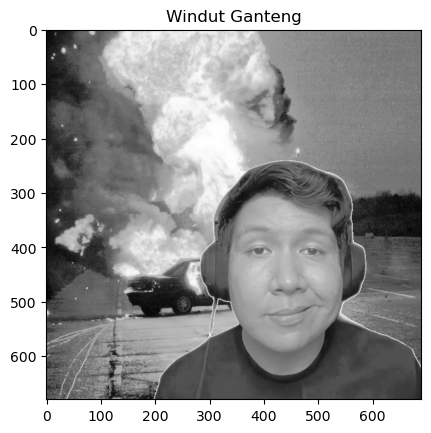

In [169]:
langit = cv.imread('assets/Langit.png')
langit_gray = cv.cvtColor(langit, cv.COLOR_BGR2GRAY)

if langit_gray.dtype != np.uint8:
    langit_gray = (langit_gray * 255).astype(np.uint8)

hasil_sempurna = histogram_specification(hasil_akhir, langit_gray)

plt.imshow(hasil_sempurna, cmap='gray', vmin=80, vmax=255)
plt.title("Windut Ganteng")
plt.show()

## Spesifikasi Histogram Lanjutan (Final Toning)

Sebagai langkah penyempurnaan komposisi, citra gabungan yang telah melalui proses *masking* (`hasil_akhir`) disesuaikan kembali rona kontrasnya agar terlihat lebih natural dan menyatu. Proses ini mencocokkan distribusi intensitas citra gabungan dengan sebuah citra referensi baru, yaitu citra pemandangan langit (`Langit.png`).

Tahapan penyesuaian akhir ini mencakup proses berikut:

* **Persiapan Citra Referensi**: Citra `Langit.png` dimuat dan langsung dikonversi ke dalam ruang warna monokrom (*grayscale*). Pemeriksaan tipe data dilakukan untuk memastikan matriks berada dalam format standar `uint8` (0-255).
* **Transformasi Karakteristik (*Matching*)**: Fungsi `histogram_specification` kembali dipanggil. Kali ini, citra gabungan (`hasil_akhir`) bertindak sebagai citra sumber, sedangkan citra langit (`langit_gray`) bertindak sebagai target. Hasilnya, *tone* keabuan pada objek manusia dan ledakan akan bergeser mengikuti karakteristik pencahayaan dari citra langit.
* **Manipulasi Kontras Visual (Clamping)**: Visualisasi citra hasil (`hasil_sempurna`) dirender menggunakan parameter pembatasan yang spesifik, yaitu `vmin=80` dan `vmax=255`. Modifikasi nilai minimum menjadi 80 ini akan memaksa semua piksel yang memiliki intensitas di bawah 80 untuk ditampilkan sebagai warna hitam pekat. Teknik ini efektif untuk memperdalam intensitas bayangan (*shadows*) dan menciptakan efek visual yang lebih sinematik dan dramatis.

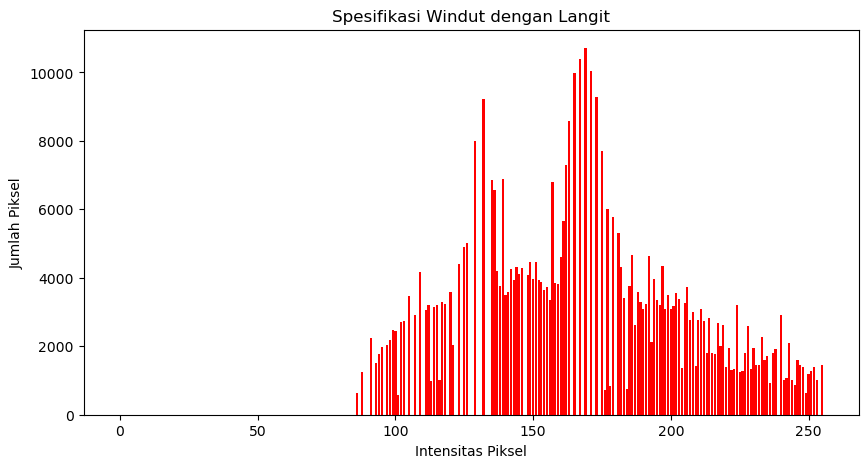

In [170]:
hist_hasil = make_hist(hasil_sempurna)

plot_histogram(hist_hasil, "Spesifikasi Windut dengan Langit", "red")

## Visualisasi Histogram Hasil Akhir

Sebagai tahap penutup dari rangkaian pemrosesan, visualisasi histogram kembali dilakukan terhadap citra hasil akhir (`hasil_sempurna`). Langkah ini bertujuan untuk memvalidasi secara kuantitatif transformasi rona citra setelah disesuaikan dengan referensi pemandangan langit.

Proses visualisasi ini mencakup dua instruksi sederhana:

* **Kalkulasi Distribusi Final (`make_hist`)**: Fungsi ini mengekstrak dan menghitung ulang frekuensi kemunculan setiap nilai intensitas piksel dari matriks citra gabungan tahap akhir.
* **Representasi Grafis (`plot_histogram`)**: Data hasil perhitungan tersebut kemudian direpresentasikan dalam bentuk grafik batang (*bar chart*) berwarna merah.
* **Tujuan Analisis**: Melalui pemetaan ini, kita dapat mengamati pergeseran kurva intensitas yang membuktikan bahwa karakteristik pencahayaan citra komposit telah berhasil beradaptasi dengan *tone* dari citra referensi (langit), menghasilkan distribusi rona yang lebih seimbang secara keseluruhan.

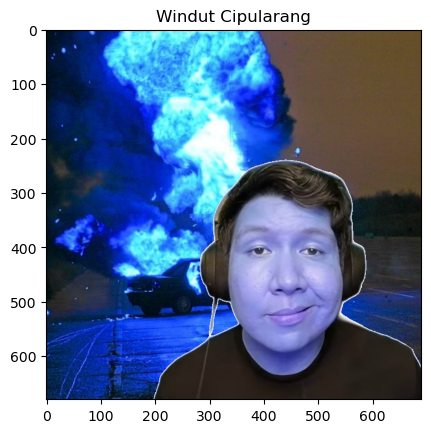

In [171]:
windut_color = cv.imread('assets/Windut.png')

background_color = meledak_utuh.copy()
if len(background_color.shape) == 3:
    background_color = background_color[:, :, :3][:, :, ::-1] 

if len(background_color.shape) == 2:
    background_color = np.stack((background_color,) * 3, axis=-1)

if background_color.max() <= 1.0:
    background_color = (background_color * 255).astype(np.uint8)

background_color = background_color.astype(np.uint8)

h_bg, w_bg, _ = background_color.shape
h_w, w_w, _ = windut_color.shape

h_min = min(h_bg, h_w)
w_min = min(w_bg, w_w)

background_crop = background_color[0:h_min, 0:w_min]
windut_crop = windut_color[0:h_min, 0:w_min]

hasil = np.zeros((h_min, w_min, 3), dtype=np.uint8)

batas_putih = 245

for y in range(h_min):
    for x in range(w_min):
        b = windut_crop[y, x, 0]
        g = windut_crop[y, x, 1]
        r = windut_crop[y, x, 2]
        
        if not (b > batas_putih and g > batas_putih and r > batas_putih):
            hasil[y, x] = windut_crop[y, x]
        else:
            hasil[y, x] = background_crop[y, x]

plt.imshow(hasil)
plt.title("Windut Cipularang")
plt.show()

## Penggabungan Citra Berwarna (Color Masking)

Tahap ini mengimplementasikan teknik *masking* pada citra berwarna, sekaligus mendemonstrasikan manipulasi format saluran warna untuk menghasilkan efek visual tertentu. Objek manusia digabungkan dengan latar belakang ledakan menggunakan seleksi warna spesifik.

Proses algoritma ini mencakup langkah-langkah berikut:

* **Manipulasi Saluran Warna (BGR)**: Citra objek dibaca menggunakan OpenCV yang secara bawaan menghasilkan format **BGR** (*Blue, Green, Red*). Untuk menyelaraskan rona, citra latar belakang (`meledak_utuh`) secara manual dibalik urutan salurannya (`[::-1]`) dari RGB menjadi BGR.
* **Sinkronisasi Resolusi Citra**: Dimensi kedua matriks citra diselaraskan dengan mencari ukuran tinggi dan lebar minimum (`h_min`, `w_min`). Kedua citra kemudian dipotong (*cropped*) agar berukuran persis sama, mencegah terjadinya *error* akibat ketidakcocokan indeks matriks.
* **Algoritma Masking Berbasis Piksel**: Sebuah kanvas kosong (`hasil`) dialokasikan. Melalui perulangan ganda, program mengekstraksi nilai intensitas warna Biru, Hijau, dan Merah (B, G, R) dari setiap titik piksel pada citra objek.
* **Seleksi Ambang Batas Putih**: Algoritma mendeteksi area latar belakang asli dengan mengecek apakah nilai B, G, dan R semuanya berada di atas ambang batas putih (245). Jika kriteria ini tidak terpenuhi (berarti itu adalah bagian objek manusia), piksel asli dipertahankan. Jika terpenuhi (area latar putih), piksel tersebut diganti dengan potongan gambar ledakan.
* **Visualisasi Efek Matplotlib**: Hasil akhir dirender menggunakan `plt.imshow()`. Karena matriks citra murni dipertahankan dalam format BGR, pustaka Matplotlib (yang mengekspektasikan format RGB) secara otomatis menukar saluran merah dan birunya. Pertukaran ini secara sengaja dibiarkan untuk menciptakan rona kebiruan yang dramatis pada seluruh komposisi gambar.